In [54]:
import os, glob

# Find all v3 derived files in processed/
patterns = [
    'articles_with_covariates_*_v3*.csv',
    'covariate_distributions_*_v3*.png',
    'covariates_by_country_*_v3*.png',
    'covariates_vs_vader_*_v3*.png',
]

found = []
for p in patterns:
    found.extend(glob.glob(f'{DATA_PROCESSED}/{p}'))

print('Files to delete:')
for f in found:
    size_kb = os.path.getsize(f) / 1024
    print(f'  {os.path.basename(f):60s} {size_kb:>8.1f} KB')

print(f'\nTotal: {len(found)} files')
print('\nIf this looks right, run the next cell to delete.')

Files to delete:
  articles_with_covariates_2025_v3_balanced.csv                  4388.1 KB
  covariate_distributions_2025_v3_balanced.png                     79.4 KB
  covariates_by_country_2025_v3_balanced.png                       90.0 KB
  covariates_vs_vader_2025_v3_balanced.png                        388.0 KB

Total: 4 files

If this looks right, run the next cell to delete.


In [55]:
for f in found:
    os.remove(f)
    print(f'Deleted: {os.path.basename(f)}')
print(f'\n{len(found)} files removed.')

Deleted: articles_with_covariates_2025_v3_balanced.csv
Deleted: covariate_distributions_2025_v3_balanced.png
Deleted: covariates_by_country_2025_v3_balanced.png
Deleted: covariates_vs_vader_2025_v3_balanced.png

4 files removed.


# Syntactic Covariates — Word, Sentence, and Paragraph Length

**Project:** SPZ — Geographic Bias in Pre-Trained Sentiment Classifiers

**Author:** Rezvaneh Mousavi | JLU Giessen | M.Sc. Data Analytics

**Supervisor:** Prof. Dr. Stefan Hennemann

---

**Purpose of this notebook:**

Compute three syntactic style features for every article in the balanced corpus:

- **Average word length** (characters per word)
- **Average sentence length** (words per sentence)
- **Average paragraph length** (sentences per paragraph)

These features are **statistical control variables** for the regression in Notebook 06 — not classifiers. The reasoning, following Hennemann's methodological requirement: non-native English writers (e.g. Indian or Pakistani journalists) may write English in stylistically distinct ways. If sentence length and word length differ across countries, classifier output may differ for reasons unrelated to actual sentiment. Including these as covariates in the regression separates *style variation* from *sentiment variation*.

**Two diagnostic checks** are performed before passing results to NB06:

1. **Do covariates differ by country?** (Kruskal-Wallis) — if no, controls are unnecessary.
2. **Do covariates correlate with sentiment scores?** (Pearson + Spearman) — if no, controlling for them will not change the regression result.

If both checks pass, controls are warranted and NB06 can proceed.

**Input:** `articles_with_sentiment_2025_v3_balanced.csv` (from Notebook 02)

**Output:** `articles_with_covariates_2025_v3_balanced.csv`


---

## 0. Setup


In [56]:
# NLTK and standard scientific stack — all pre-installed in Colab
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats

import nltk
# Both names needed for cross-version compatibility (NLTK >=3.8 uses punkt_tab)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize, word_tokenize

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 11, 'figure.facecolor': 'white'})
print('All imports loaded successfully.')


All imports loaded successfully.


In [57]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
# --- Paths (must match Notebook 02) ---
DRIVE_BASE = '/content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule'
DATA_PROCESSED = f'{DRIVE_BASE}/data/processed'

TARGET_YEAR = '2025'
DATA_VERSION = 'v3'

# Input: output of Notebook 02 (balanced + sentiment scores)
INPUT_PATH = f'{DATA_PROCESSED}/articles_with_sentiment_{TARGET_YEAR}_{DATA_VERSION}_balanced.csv'

# Output: same DataFrame plus three covariate columns
OUTPUT_PATH = f'{DATA_PROCESSED}/articles_with_covariates_{TARGET_YEAR}_{DATA_VERSION}_balanced.csv'

assert os.path.exists(INPUT_PATH), f'Input file not found: {INPUT_PATH}'
print(f'Input:  {INPUT_PATH}')
print(f'Output: {OUTPUT_PATH}')


Input:  /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed/articles_with_sentiment_2025_v3_balanced.csv
Output: /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed/articles_with_covariates_2025_v3_balanced.csv


---

## 1. Load Data and Identify Text Column

The covariates should describe the publication's general writing style. The full article body is preferred over the lead alone because:

- The lead is typically a single paragraph, making `avg_paragraph_length` uninformative.
- Style is more reliably measured on longer text.

We first inspect the available columns and select the longest available text field. If only `lead_text` is available, we fall back to it and document the limitation in the report.


In [59]:
df = pd.read_csv(INPUT_PATH)
print(f'Loaded {len(df)} articles')
print(f'\nAvailable columns:')
for col in df.columns:
    sample_lengths = df[col].dropna().astype(str).str.len()
    if len(sample_lengths) > 0 and sample_lengths.mean() > 50:
        print(f'  {col:<25s} (text-like; mean length: {sample_lengths.mean():.0f} chars)')
    else:
        print(f'  {col}')


Loaded 1224 articles

Available columns:
  url                       (text-like; mean length: 107 chars)
  date
  text                      (text-like; mean length: 3156 chars)
  lead_text                 (text-like; mean length: 235 chars)
  lead_status
  registered_domain
  domain_suffix
  country_url
  vader_compound
  vader_label
  roberta_compound
  roberta_label


In [60]:
# Pick the best available text column.
# Preference order: full body > main text > lead.
TEXT_COLUMN_CANDIDATES = ['body', 'text', 'full_text', 'content', 'article_text', 'lead_text']

TEXT_COL = None
for candidate in TEXT_COLUMN_CANDIDATES:
    if candidate in df.columns:
        TEXT_COL = candidate
        break

assert TEXT_COL is not None, 'No usable text column found.'
print(f'Using text column: {TEXT_COL}')
print(f'  Non-null:   {df[TEXT_COL].notna().sum()} / {len(df)}')
print(f'  Mean chars: {df[TEXT_COL].dropna().astype(str).str.len().mean():.0f}')
print(f'  Median chars: {df[TEXT_COL].dropna().astype(str).str.len().median():.0f}')

if TEXT_COL == 'lead_text':
    print('\n  NOTE: Falling back to lead_text. Paragraph length will be less meaningful.')
    print('  Document this limitation in the report.')


Using text column: text
  Non-null:   1224 / 1224
  Mean chars: 3156
  Median chars: 2832


---

## 2. Define Covariate Functions

Three independent functions operate on a single text string and return float values. Wrapped in a single `compute_covariates` for vectorised application.

**Word-level rules:**
- Tokenise with NLTK's `word_tokenize`.
- Keep only tokens containing at least one alphanumeric character (drops `,` `.` `--` etc.).
- Word length = character count of the kept token.

**Sentence-level rules:**
- Tokenise with NLTK's `sent_tokenize` (Punkt).
- Sentence length = word count (after the alphanumeric filter above).

**Paragraph-level rules:**
- Split text on blank lines (`\n\s*\n`); fall back to single newlines if no blank lines exist.
- Paragraph length = sentence count within the paragraph.


In [61]:
import re

HTML_TAG_RE = re.compile(r'<[^>]+>')
WHITESPACE_RE = re.compile(r'\s+')

def strip_html(text):
    """Remove HTML tags, replacing them with whitespace to preserve word boundaries."""
    if pd.isna(text):
        return text
    cleaned = HTML_TAG_RE.sub(' ', str(text))
    cleaned = WHITESPACE_RE.sub(' ', cleaned)
    return cleaned.strip()


def compute_covariates(text):
    """
    Compute three syntactic covariates for one article.
    HTML tags are stripped before tokenization (some domains retain raw HTML in body text).
    """
    if pd.isna(text) or not str(text).strip():
        return {'avg_word_length': np.nan, 'avg_sentence_length': np.nan, 'avg_paragraph_length': np.nan,
                'n_words': 0, 'n_sentences': 0, 'n_paragraphs': 0}

    # Strip HTML before any further processing
    text = strip_html(text)
    if not text:
        return {'avg_word_length': np.nan, 'avg_sentence_length': np.nan, 'avg_paragraph_length': np.nan,
                'n_words': 0, 'n_sentences': 0, 'n_paragraphs': 0}

    # Paragraphs (note: HTML stripping collapsed all whitespace, so paragraph splitting now relies on `. ` patterns
    # plus original \n which may have been collapsed. We use sentence count as proxy for very-short articles.)
    paragraphs = [p.strip() for p in re.split(r'\n\s*\n', text) if p.strip()]
    if not paragraphs:
        paragraphs = [p.strip() for p in text.split('\n') if p.strip()]
    if not paragraphs:
        paragraphs = [text]

    try:
        sentences = sent_tokenize(text)
    except Exception:
        sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if s.strip()]
    if not sentences:
        return {'avg_word_length': np.nan, 'avg_sentence_length': np.nan, 'avg_paragraph_length': np.nan,
                'n_words': 0, 'n_sentences': 0, 'n_paragraphs': len(paragraphs)}

    all_words = []
    for s in sentences:
        try:
            tokens = word_tokenize(s)
        except Exception:
            tokens = s.split()
        words = [t for t in tokens if any(c.isalnum() for c in t)]
        all_words.extend(words)
    if not all_words:
        return {'avg_word_length': np.nan, 'avg_sentence_length': np.nan, 'avg_paragraph_length': np.nan,
                'n_words': 0, 'n_sentences': len(sentences), 'n_paragraphs': len(paragraphs)}

    return {
        'avg_word_length': float(np.mean([len(w) for w in all_words])),
        'avg_sentence_length': len(all_words) / len(sentences),
        'avg_paragraph_length': len(sentences) / len(paragraphs),
        'n_words': len(all_words), 'n_sentences': len(sentences), 'n_paragraphs': len(paragraphs),
    }


# Find the deccanherald article by URL (we know it's the worst from the diagnosis above)
TARGET_URL = 'https://www.deccanherald.com/world/russias-gerasimov-says-putin-ordered-ukraine-buffer-zone-expansion-in-2026-3847436'

# Reload from input to get fresh data with text column
df_raw = pd.read_csv(INPUT_PATH)
target_row = df_raw[df_raw['url'] == TARGET_URL].iloc[0]
worst_text = target_row['text']

print('Before HTML strip — first 200 chars:')
print(repr(worst_text[:200]))
print('\nAfter HTML strip — first 200 chars:')
print(repr(strip_html(worst_text)[:200]))
print('\nNew covariates for this article:')
print(compute_covariates(worst_text))
print('\nFor comparison: previously 1 sentence, 550 words.')
print('After fix should be ~20–30 sentences, similar word count, sentence length 15–25.')

Before HTML strip — first 200 chars:
'<p><a href="https://www.deccanherald.com/tags/russia">Russia</a>’s top general said its forces were pressing forward in northeastern Ukraine and President <a href="https://www.deccanherald.com/tags/vl'

After HTML strip — first 200 chars:
'Russia ’s top general said its forces were pressing forward in northeastern Ukraine and President Vladimir Putin had ordered expansion of territory Moscow calls a buffer zone there in 2026, Russian ne'

New covariates for this article:
{'avg_word_length': 4.9757085020242915, 'avg_sentence_length': 27.444444444444443, 'avg_paragraph_length': 18.0, 'n_words': 494, 'n_sentences': 18, 'n_paragraphs': 1}

For comparison: previously 1 sentence, 550 words.
After fix should be ~20–30 sentences, similar word count, sentence length 15–25.


---

## 3. Compute Covariates for All Articles

Checkpoint: if the output file already exists, load it; otherwise compute and save.


In [62]:
# === CHECKPOINT: Covariates ===
if os.path.exists(OUTPUT_PATH):
    print(f'Checkpoint found: {OUTPUT_PATH}')
    df = pd.read_csv(OUTPUT_PATH)
    print(f'Loaded {len(df)} articles with covariates.')
else:
    print(f'Computing covariates on {len(df)} articles ({TEXT_COL})...')
    cov_records = df[TEXT_COL].apply(compute_covariates)

    df['avg_word_length']      = cov_records.apply(lambda d: d['avg_word_length'])
    df['avg_sentence_length']  = cov_records.apply(lambda d: d['avg_sentence_length'])
    df['avg_paragraph_length'] = cov_records.apply(lambda d: d['avg_paragraph_length'])
    df['n_words']              = cov_records.apply(lambda d: d['n_words'])
    df['n_sentences']          = cov_records.apply(lambda d: d['n_sentences'])
    df['n_paragraphs']         = cov_records.apply(lambda d: d['n_paragraphs'])

    df.to_csv(OUTPUT_PATH, index=False)
    print(f'Saved {len(df)} articles with covariates to:')
    print(f'  {OUTPUT_PATH}')

# Sanity check: how many articles have valid covariates?
valid_mask = df[['avg_word_length', 'avg_sentence_length', 'avg_paragraph_length']].notna().all(axis=1)
print(f'\nArticles with valid covariates: {valid_mask.sum()} / {len(df)}')
if (~valid_mask).any():
    print(f'Missing covariates breakdown:')
    print(df.loc[~valid_mask, 'country_url'].value_counts().to_string())


Computing covariates on 1224 articles (text)...
Saved 1224 articles with covariates to:
  /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed/articles_with_covariates_2025_v3_balanced.csv

Articles with valid covariates: 1224 / 1224


---

## 4. Covariate Distributions — Overall


In [63]:
df_valid = df[df[['avg_word_length', 'avg_sentence_length', 'avg_paragraph_length']].notna().all(axis=1)].copy()

print('=' * 70)
print('OVERALL COVARIATE DISTRIBUTIONS')
print('=' * 70)
print(f'{"Covariate":>22s} {"mean":>10s} {"std":>10s} {"min":>10s} {"median":>10s} {"max":>10s}')
print('-' * 70)
for col in ['avg_word_length', 'avg_sentence_length', 'avg_paragraph_length']:
    s = df_valid[col]
    print(f'{col:>22s} {s.mean():10.3f} {s.std():10.3f} {s.min():10.3f} {s.median():10.3f} {s.max():10.3f}')
print('=' * 70)


OVERALL COVARIATE DISTRIBUTIONS
             Covariate       mean        std        min     median        max
----------------------------------------------------------------------
       avg_word_length      5.027      0.485      3.757      5.007      6.492
   avg_sentence_length     28.191     21.416      6.133     23.908    332.000
  avg_paragraph_length     21.743     17.970      1.000     18.000    187.000


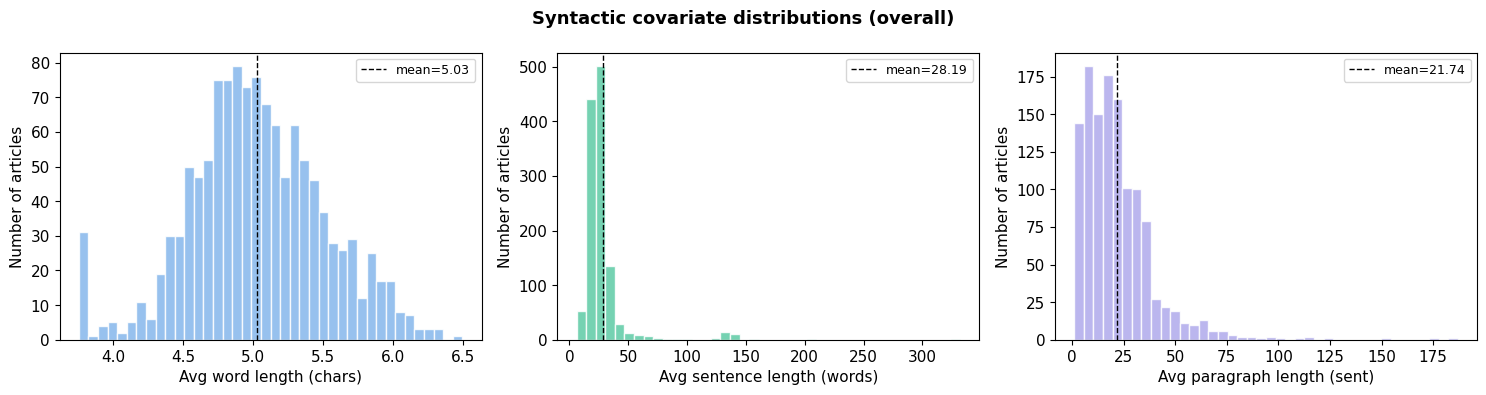

Figure saved to /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed/covariate_distributions_2025_v3_balanced.png


In [64]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Syntactic covariate distributions (overall)', fontsize=13, fontweight='bold')

for ax, (col, label, color) in zip(axes, [
    ('avg_word_length',      'Avg word length (chars)',     '#85B7EB'),
    ('avg_sentence_length',  'Avg sentence length (words)', '#5DCAA5'),
    ('avg_paragraph_length', 'Avg paragraph length (sent)', '#AFA9EC'),
]):
    ax.hist(df_valid[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df_valid[col].mean(), color='black', linestyle='--', linewidth=1, label=f'mean={df_valid[col].mean():.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Number of articles')
    ax.legend(fontsize=9)

plt.tight_layout()
fig_path = f'{DATA_PROCESSED}/covariate_distributions_{TARGET_YEAR}_{DATA_VERSION}_balanced.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {fig_path}')


---

## 5. Covariates by Country

Mean covariate values per country. If style differs by country, this is the table that shows it.


In [65]:
country_summary = df_valid.groupby('country_url').agg(
    n=('avg_word_length', 'count'),
    word_len_mean=('avg_word_length', 'mean'),
    word_len_std=('avg_word_length', 'std'),
    sent_len_mean=('avg_sentence_length', 'mean'),
    sent_len_std=('avg_sentence_length', 'std'),
    para_len_mean=('avg_paragraph_length', 'mean'),
    para_len_std=('avg_paragraph_length', 'std'),
).round(3).sort_values('word_len_mean')

print('=' * 100)
print('SYNTACTIC COVARIATES BY COUNTRY')
print('=' * 100)
print(country_summary.to_string())
print('=' * 100)


SYNTACTIC COVARIATES BY COUNTRY
               n  word_len_mean  word_len_std  sent_len_mean  sent_len_std  para_len_mean  para_len_std
country_url                                                                                            
KR           102          4.748         0.663         20.838         6.021         16.441        17.674
UK           102          4.810         0.419         24.594         5.380         22.304        17.760
US           102          4.837         0.369         24.869        12.432         27.784        24.166
SG           102          4.841         0.298         25.712         5.133         20.608        17.814
ZA           102          4.905         0.328         21.287         4.909         28.706        11.222
KE           102          4.938         0.342         19.633         4.361         34.657        21.291
AU           102          4.973         0.639         52.771        48.305         15.980        13.267
IN           102          5.084 

---

## 6. Diagnostic 1 — Do Covariates Differ by Country?

Kruskal-Wallis test for each covariate. If `p < 0.05`, the covariate differs across countries and is worth including as a control. If `p > 0.05`, controlling for it will not change the regression.


In [66]:
countries = sorted(df_valid['country_url'].unique())

print('Kruskal-Wallis H test per covariate:\n')
print(f'{"Covariate":>22s} {"H":>10s} {"p":>14s} {"Significant?":>15s}')
print('-' * 65)

kw_results = {}
for col in ['avg_word_length', 'avg_sentence_length', 'avg_paragraph_length']:
    groups = [df_valid[df_valid['country_url'] == c][col].values for c in countries]
    h, p = stats.kruskal(*groups)
    kw_results[col] = (h, p)
    sig = '*** (p<0.001)' if p < 0.001 else ('** (p<0.01)' if p < 0.01 else ('* (p<0.05)' if p < 0.05 else 'n.s.'))
    print(f'{col:>22s} {h:10.2f} {p:14.2e} {sig:>15s}')

n_sig = sum(1 for h, p in kw_results.values() if p < 0.05)
print(f'\n{n_sig} of 3 covariates differ significantly across countries.')
if n_sig == 0:
    print('=> No country-level style differences detected. Covariates may not be necessary controls.')
elif n_sig == 3:
    print('=> All three covariates show country-level differences. All are warranted as controls.')
else:
    print('=> Mixed result. Include only the significant covariates in the regression.')


Kruskal-Wallis H test per covariate:

             Covariate          H              p    Significant?
-----------------------------------------------------------------
       avg_word_length     268.03       4.65e-51   *** (p<0.001)
   avg_sentence_length     284.14       1.91e-54   *** (p<0.001)
  avg_paragraph_length     196.94       3.20e-36   *** (p<0.001)

3 of 3 covariates differ significantly across countries.
=> All three covariates show country-level differences. All are warranted as controls.


---

## 7. Diagnostic 2 — Do Covariates Correlate with Sentiment?

If a covariate has near-zero correlation with sentiment, controlling for it will not change the regression coefficient on `country`. Both Pearson (linear) and Spearman (rank) are reported.


In [67]:
print('Correlation between covariates and sentiment scores\n')
print(f'{"Covariate":>22s}  {"vs VADER":>20s}  {"vs RoBERTa":>20s}')
print(f'{"":>22s}  {"Pearson r (p)":>20s}  {"Pearson r (p)":>20s}')
print('-' * 75)

for col in ['avg_word_length', 'avg_sentence_length', 'avg_paragraph_length']:
    sub = df_valid[[col, 'vader_compound', 'roberta_compound']].dropna()
    rv, pv = stats.pearsonr(sub[col], sub['vader_compound'])
    rr, pr = stats.pearsonr(sub[col], sub['roberta_compound'])
    print(f'{col:>22s}  {rv:+.3f} ({pv:.1e})    {rr:+.3f} ({pr:.1e})')

print()
print(f'{"Covariate":>22s}  {"vs VADER":>20s}  {"vs RoBERTa":>20s}')
print(f'{"":>22s}  {"Spearman rho (p)":>20s}  {"Spearman rho (p)":>20s}')
print('-' * 75)
for col in ['avg_word_length', 'avg_sentence_length', 'avg_paragraph_length']:
    sub = df_valid[[col, 'vader_compound', 'roberta_compound']].dropna()
    rv, pv = stats.spearmanr(sub[col], sub['vader_compound'])
    rr, pr = stats.spearmanr(sub[col], sub['roberta_compound'])
    print(f'{col:>22s}  {rv:+.3f} ({pv:.1e})    {rr:+.3f} ({pr:.1e})')


Correlation between covariates and sentiment scores

             Covariate              vs VADER            vs RoBERTa
                               Pearson r (p)         Pearson r (p)
---------------------------------------------------------------------------
       avg_word_length  +0.034 (2.4e-01)    +0.031 (2.8e-01)
   avg_sentence_length  -0.037 (1.9e-01)    -0.029 (3.1e-01)
  avg_paragraph_length  +0.135 (2.2e-06)    +0.107 (1.9e-04)

             Covariate              vs VADER            vs RoBERTa
                            Spearman rho (p)      Spearman rho (p)
---------------------------------------------------------------------------
       avg_word_length  +0.015 (5.9e-01)    +0.008 (7.7e-01)
   avg_sentence_length  +0.016 (5.7e-01)    -0.017 (5.6e-01)
  avg_paragraph_length  +0.144 (3.9e-07)    +0.090 (1.7e-03)


---

## 8. Visualisations


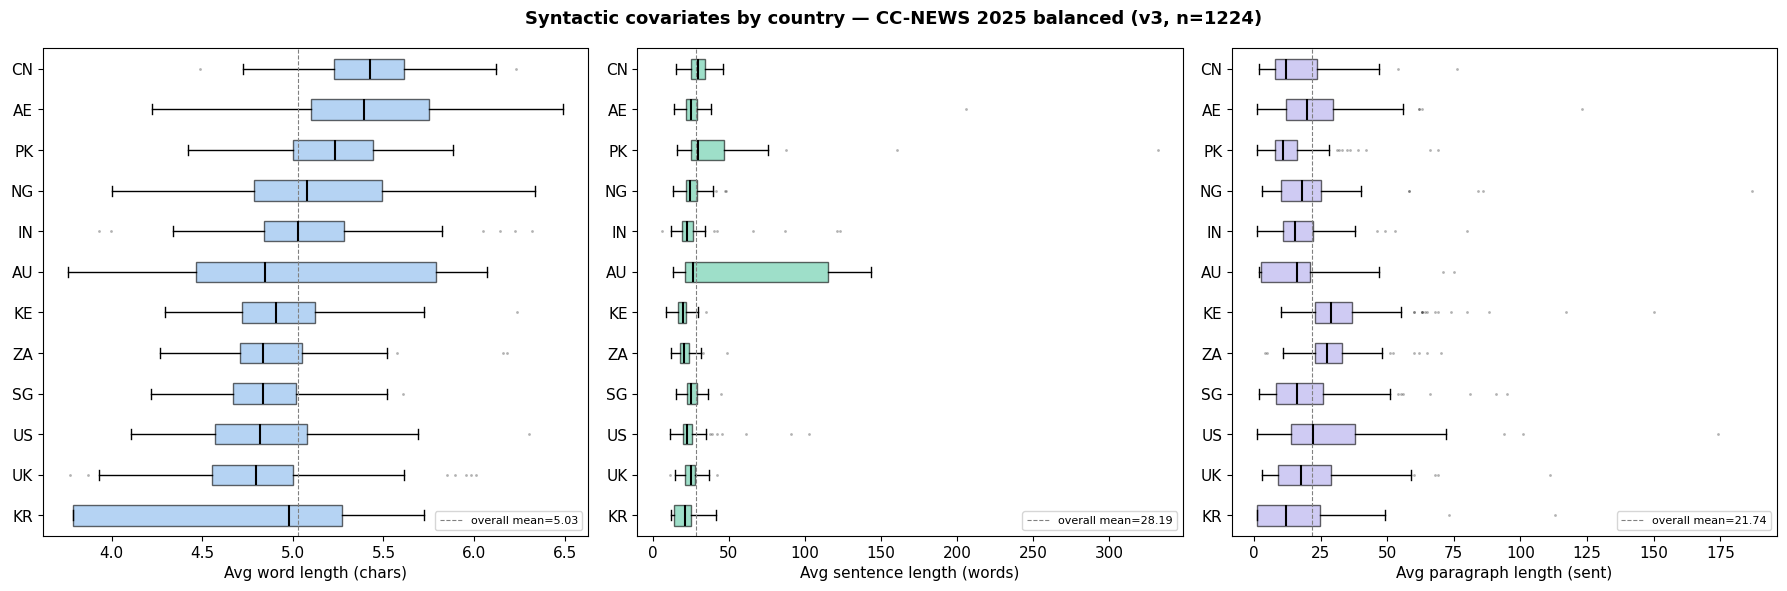

Figure saved to /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed/covariates_by_country_2025_v3_balanced.png


In [68]:
# Country order from the by-country table (sorted by avg_word_length)
country_order = country_summary.index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Syntactic covariates by country — CC-NEWS {TARGET_YEAR} balanced ({DATA_VERSION}, n={len(df_valid)})',
             fontsize=13, fontweight='bold')

palette = ['#85B7EB', '#5DCAA5', '#AFA9EC']

for ax, (col, label, color) in zip(axes, [
    ('avg_word_length',      'Avg word length (chars)',     '#85B7EB'),
    ('avg_sentence_length',  'Avg sentence length (words)', '#5DCAA5'),
    ('avg_paragraph_length', 'Avg paragraph length (sent)', '#AFA9EC'),
]):
    data = [df_valid[df_valid['country_url'] == c][col].values for c in country_order]
    bp = ax.boxplot(data, vert=False, labels=country_order, patch_artist=True,
                    medianprops=dict(color='black', linewidth=1.5),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_xlabel(label)
    grand_mean = df_valid[col].mean()
    ax.axvline(grand_mean, color='gray', linestyle='--', linewidth=0.8, label=f'overall mean={grand_mean:.2f}')
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
fig_path = f'{DATA_PROCESSED}/covariates_by_country_{TARGET_YEAR}_{DATA_VERSION}_balanced.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {fig_path}')


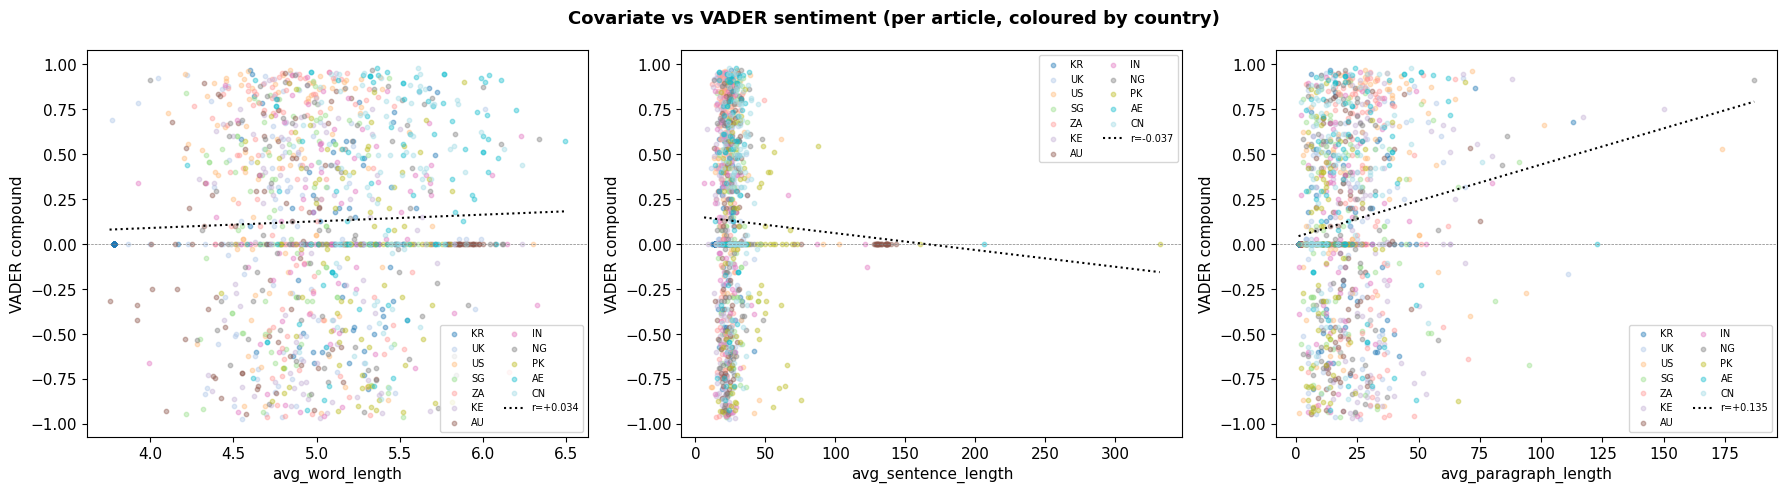

Figure saved to /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed/covariates_vs_vader_2025_v3_balanced.png


In [69]:
# Scatter: each covariate vs VADER, coloured by country
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Covariate vs VADER sentiment (per article, coloured by country)',
             fontsize=13, fontweight='bold')

cmap = plt.cm.tab20
country_colors = {c: cmap(i / max(len(country_order)-1, 1)) for i, c in enumerate(country_order)}

for ax, col in zip(axes, ['avg_word_length', 'avg_sentence_length', 'avg_paragraph_length']):
    for c in country_order:
        sub = df_valid[df_valid['country_url'] == c]
        ax.scatter(sub[col], sub['vader_compound'], s=10, alpha=0.4,
                   color=country_colors[c], label=c)
    ax.set_xlabel(col)
    ax.set_ylabel('VADER compound')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    # Add overall regression line
    sub_all = df_valid[[col, 'vader_compound']].dropna()
    if len(sub_all) > 2:
        slope, intercept, r, p, _ = stats.linregress(sub_all[col], sub_all['vader_compound'])
        xs = np.array([sub_all[col].min(), sub_all[col].max()])
        ax.plot(xs, intercept + slope * xs, color='black', linewidth=1.5, linestyle=':',
                label=f'r={r:+.3f}')
    ax.legend(fontsize=7, loc='best', ncol=2)

plt.tight_layout()
fig_path = f'{DATA_PROCESSED}/covariates_vs_vader_{TARGET_YEAR}_{DATA_VERSION}_balanced.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {fig_path}')


---

## 9. Summary and Next Steps

**What this notebook delivered:**

- Three syntactic covariates per article: `avg_word_length`, `avg_sentence_length`, `avg_paragraph_length`.
- Diagnostic 1 (Kruskal-Wallis): tests whether style differs by country — *necessary* for covariates to matter as controls.
- Diagnostic 2 (Pearson + Spearman): tests whether covariates correlate with sentiment — *sufficient* for them to change the regression.

**Decision rule for NB06 (regression):**

| Diagnostic 1 | Diagnostic 2 | Action in NB06 |
|---|---|---|
| Significant | Significant | Include covariate as control |
| Significant | Not significant | Optional — controls won't change country effect |
| Not significant | — | Drop covariate from regression |

**Output:** `articles_with_covariates_2025_v3_balanced.csv` — same rows as NB02 output, plus six new columns (3 covariates + 3 raw counts).

**Subsequent notebooks:**

- **NB04** — Politics-only topic filter (URL + keyword pattern matching, reusing previous project's pipeline).
- **NB05** — Manual annotation (~150–200 articles) for gold standard validation.
- **NB06** — Regression with covariates as controls. Tests the SPZ hypothesis formally.


In [70]:
# === Sentence-length outlier diagnosis ===
import pandas as pd

# Reload from the covariates checkpoint to make sure we're working with fresh data
df = pd.read_csv(OUTPUT_PATH)

# 1. How extreme are the outliers?
print('Distribution of avg_sentence_length:')
print(df['avg_sentence_length'].describe(percentiles=[.5, .9, .95, .99, .995]).to_string())

# 2. How many articles cross various thresholds?
print('\nArticles by threshold:')
for threshold in [40, 60, 100, 200]:
    n = (df['avg_sentence_length'] > threshold).sum()
    pct = 100 * n / len(df)
    print(f'  > {threshold:>4d} words/sentence: {n:4d} articles ({pct:.1f}%)')

# 3. Are outliers concentrated in specific countries / domains?
mask_extreme = df['avg_sentence_length'] > 100
print(f'\nArticles with avg_sentence_length > 100 ({mask_extreme.sum()} total):')
print('  By country:')
print(df.loc[mask_extreme, 'country_url'].value_counts().to_string())
print('\n  By domain (top 10):')
print(df.loc[mask_extreme, 'registered_domain'].value_counts().head(10).to_string())

# 4. Top 5 worst — what URLs are these?
print('\nTop 5 worst offenders:')
worst_cols = ['country_url', 'registered_domain', 'avg_sentence_length', 'n_sentences', 'n_words', 'n_paragraphs']
print(df.nlargest(5, 'avg_sentence_length')[worst_cols].to_string())

# 5. Look at the actual text of the single worst article
print('\n' + '='*80)
print('TEXT SAMPLE — single worst article (first 800 chars)')
print('='*80)
worst_row = df.loc[df['avg_sentence_length'].idxmax()]
print(f"Country:  {worst_row['country_url']}")
print(f"Domain:   {worst_row['registered_domain']}")
print(f"URL:      {worst_row['url']}")
print(f"Stats:    {worst_row['n_sentences']} sentences, {worst_row['n_words']} words, {worst_row['n_paragraphs']} paragraphs")
print(f"Avg sent length: {worst_row['avg_sentence_length']:.1f}")
print('-'*80)
print(worst_row['text'][:800])
print('...' if len(worst_row['text']) > 800 else '')

Distribution of avg_sentence_length:
count    1224.000000
mean       28.190976
std        21.415548
min         6.133333
50%        23.908034
90%        35.542895
95%        48.156667
99%       136.500000
99.5%     137.442500
max       332.000000

Articles by threshold:
  >   40 words/sentence:   86 articles (7.0%)
  >   60 words/sentence:   48 articles (3.9%)
  >  100 words/sentence:   32 articles (2.6%)
  >  200 words/sentence:    2 articles (0.2%)

Articles with avg_sentence_length > 100 (32 total):
  By country:
country_url
AU    26
PK     2
IN     2
AE     1
US     1

  By domain (top 10):
registered_domain
thewest.com.au      26
urdupoint.com        2
thehansindia.com     2
khaleejtimes.com     1
cbsnews.com          1

Top 5 worst offenders:
    country_url registered_domain  avg_sentence_length  n_sentences  n_words  n_paragraphs
720          PK     urdupoint.com           332.000000            1      332             1
56           AE  khaleejtimes.com           206.000000     